# Casualties Data Analysis
This notebook performs analytical work on the cleaned data.

### 1.  Import the required libraries

In [1]:
import pandas as pd # noqa: F401
import numpy as np # noqa: F401
import matplotlib.pyplot as plt # noqa: F401
import seaborn as sns # noqa: F401
from datetime import datetime # noqa: F401

# Set display options for better readability
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")  # Set Seaborn style

### 2. Load the Dataset

In [2]:
df = pd.read_csv("../1_datasets/data/clean_datasets/casualties_cleaned_data.csv")
df.head()

,report_date,report_source,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,injured_cum,ext_injured,ext_injured_cum,ext_civdef_killed_cum,med_killed_cum,ext_med_killed_cum,press_killed_cum,ext_press_killed_cum,killed_recovered,killed_succumbed,killed_truce_new,killed_committee
0,1696636800000000000,mohtel,24,0,232,232,232,232,0,0,1610,1610,1610,0,6,6,1,1,0,0,0,0
1,1696723200000000000,mohtel,24,0,138,370,138,370,78,41,1788,178,1788,0,6,6,1,1,0,0,0,0
2,1696809600000000000,mohtel,24,8,190,560,190,560,91,61,2271,483,2271,0,6,6,3,3,0,0,0,0
3,1696896000000000000,mohtel,24,8,340,900,340,900,260,230,4000,1729,4000,0,6,6,7,7,0,0,0,0
4,1696982400000000000,mohtel,24,23,200,1100,200,1100,398,230,5184,1184,5184,0,10,10,7,7,0,0,0,0


Check Data Structure

In [3]:
df.info()  # Check columns and data types
df.describe()  # Summary statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   report_date              631 non-null    int64 
 1   report_source            631 non-null    object
 2   report_period            631 non-null    int64 
 3   ext_massacres_cum        631 non-null    int64 
 4   killed                   631 non-null    int64 
 5   killed_cum               631 non-null    int64 
 6   ext_killed               631 non-null    int64 
 7   ext_killed_cum           631 non-null    int64 
 8   ext_killed_children_cum  631 non-null    int64 
 9   ext_killed_women_cum     631 non-null    int64 
 10  injured_cum              631 non-null    int64 
 11  ext_injured              631 non-null    int64 
 12  ext_injured_cum          631 non-null    int64 
 13  ext_civdef_killed_cum    631 non-null    int64 
 14  med_killed_cum           631 non-null    i

,report_date,report_period,ext_massacres_cum,killed,killed_cum,ext_killed,ext_killed_cum,ext_killed_children_cum,ext_killed_women_cum,injured_cum,ext_injured,ext_injured_cum,ext_civdef_killed_cum,med_killed_cum,ext_med_killed_cum,press_killed_cum,ext_press_killed_cum,killed_recovered,killed_succumbed,killed_truce_new,killed_committee
count,6.310000e+02,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000,631.000000
mean,1.723853e+18,23.847861,5019.274168,82.182250,33182.450079,89.400951,37388.698891,14653.112520,9963.865293,87275.175911,210.862124,87284.931854,73.155309,784.510301,784.518225,157.702060,157.702060,1.407290,0.045959,9.825674,3.381933
std,1.575057e+16,7.527452,3791.952956,102.201622,12101.203843,110.407798,12873.871382,4400.923959,3017.625583,28653.428201,304.370297,28634.286025,28.963436,439.304067,439.295178,52.562887,52.562887,6.719827,0.337279,29.844008,42.814197
min,1.696637e+18,0.000000,0.000000,0.000000,232.000000,0.000000,232.000000,0.000000,0.000000,1610.000000,0.000000,1610.000000,0.000000,6.000000,6.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.710245e+18,24.000000,2741.000000,28.000000,26673.000000,30.500000,31228.000000,13500.000000,9000.000000,72956.500000,72.000000,72956.500000,48.000000,364.000000,364.000000,133.000000,133.000000,0.000000,0.000000,0.000000,0.000000
50%,1.723853e+18,24.000000,3498.000000,52.000000,35519.000000,54.000000,40074.000000,16456.000000,11088.000000,92537.000000,125.000000,92537.000000,79.000000,885.000000,885.000000,168.000000,168.000000,0.000000,0.000000,0.000000,0.000000
75%,1.737461e+18,24.000000,10100.000000,92.000000,42579.000000,101.500000,47134.000000,17861.000000,12316.000000,111156.500000,227.500000,111156.500000,94.000000,1155.000000,1155.000000,205.000000,205.000000,0.000000,0.000000,0.000000,0.000000
max,1.751069e+18,48.000000,12000.000000,756.000000,51857.000000,828.000000,56412.000000,18000.000000,12400.000000,133054.000000,3652.000000,133054.000000,115.000000,1583.000000,1583.000000,227.000000,227.000000,120.000000,5.000000,436.000000,697.000000


### 3. Data Cleaning & Preparation

Convert Timestamp to Readable Date

In [4]:
df["date"] = pd.to_datetime(df["report_date"], unit="ns")
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days

Calculate Daily Deaths

In [5]:
df["daily_child_deaths"] = (
    df["ext_killed_children_cum"].diff().fillna(df["ext_killed_children_cum"].iloc[0])
)
df["daily_women_deaths"] = (
    df["ext_killed_women_cum"].diff().fillna(df["ext_killed_women_cum"].iloc[0])
)
df["daily_men_deaths"] = (
    df["killed"] - df["daily_women_deaths"] - df["daily_child_deaths"]
)

Check for Missing Data

In [6]:
df.isnull().sum()  # Check for missing values

report_date                0
report_source              0
report_period              0
ext_massacres_cum          0
killed                     0
killed_cum                 0
ext_killed                 0
ext_killed_cum             0
ext_killed_children_cum    0
ext_killed_women_cum       0
injured_cum                0
ext_injured                0
ext_injured_cum            0
ext_civdef_killed_cum      0
med_killed_cum             0
ext_med_killed_cum         0
press_killed_cum           0
ext_press_killed_cum       0
killed_recovered           0
killed_succumbed           0
killed_truce_new           0
killed_committee           0
date                       0
days_since_start           0
daily_child_deaths         0
daily_women_deaths         0
daily_men_deaths           0
dtype: int64

### 4. Exploratory Data Analysis (EDA)

Total Casualties

In [7]:
total_killed = df["killed_cum"].max()
total_injured = df["injured_cum"].max()

print(f"Total Deaths: {total_killed}")
print(f"Total Injuries: {total_injured}")
print(f"Injury-to-Death Ratio: {total_injured / total_killed:.2f}")

Total Deaths: 51857
Total Injuries: 133054
Injury-to-Death Ratio: 2.57


Primary Demographics (Children, Women, Men) & Professional Groups (Medical, Press) - recognizing these group make to overlap with primary groups

In [8]:
# Total confirmed deaths
total_killed = df["killed_cum"].max()

# Primary demographics (sum = 100% of civilians)
civilian_deaths = (
    total_killed - df["med_killed_cum"].max() - df["press_killed_cum"].max()
)

demographics = pd.DataFrame(
    {
        "Category": ["Civilian", "Medical", "Press"],
        "Deaths": [
            civilian_deaths,
            df["med_killed_cum"].max(),
            df["press_killed_cum"].max(),
        ],
        "Percentage": [
            civilian_deaths / total_killed * 100,
            df["med_killed_cum"].max() / total_killed * 100,
            df["press_killed_cum"].max() / total_killed * 100,
        ],
    }
)

# Civilian breakdown
civ_breakdown = pd.DataFrame(
    {
        "Group": ["Children", "Women", "Men"],
        "Deaths": [18000, 12400, 21457],
        "Percentage": [
            18000 / civilian_deaths * 100,
            12400 / civilian_deaths * 100,
            21457 / civilian_deaths * 100,
        ],
    }
)

View 1: Civilian vs Professionals

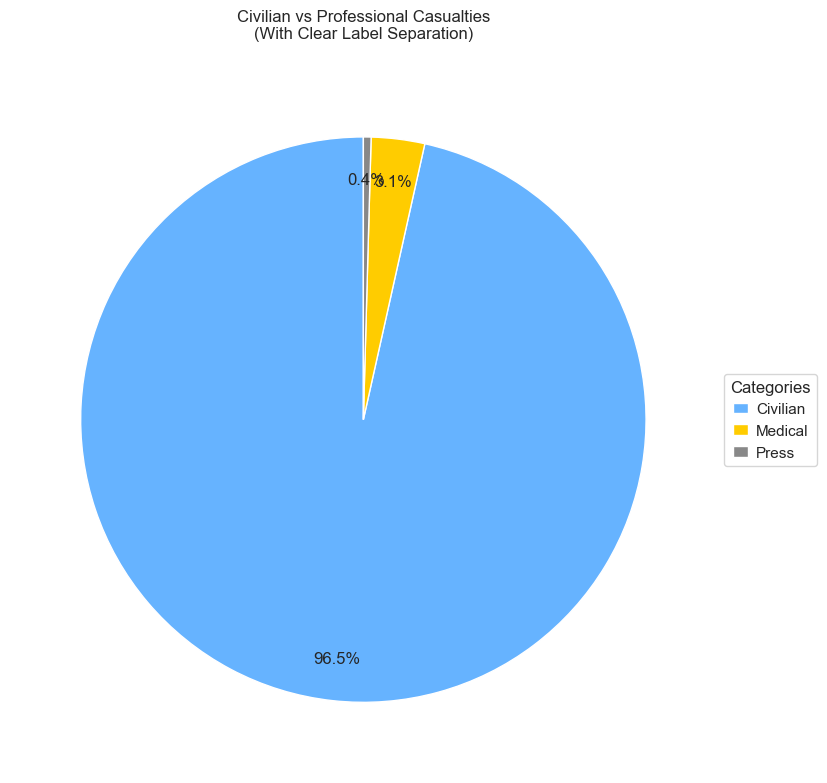

In [9]:
plt.figure(figsize=(12, 8))

# Create the pie chart with labels
wedges, texts, autotexts = plt.pie(
    demographics["Deaths"],
    labels=None,
    autopct="%1.1f%%",
    colors=["#66B3FF", "#FFCC00", "#888888"],
    startangle=90,
    pctdistance=0.85,
    textprops={"fontsize": 12},
)


plt.legend(
    wedges,
    demographics["Category"],
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    handlelength=1,
    handletextpad=0.5,
)

plt.title("Civilian vs Professional Casualties\n(With Clear Label Separation)", pad=20)
plt.tight_layout()
plt.show()

View 2: Civilian Demographics

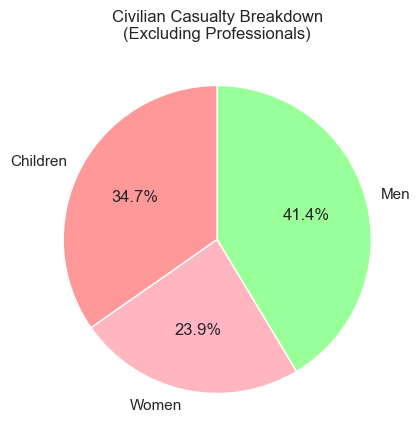

In [10]:
plt.figure(figsize=(10, 5))
plt.pie(
    civ_breakdown["Deaths"],
    labels=civ_breakdown["Group"],
    autopct="%1.1f%%",
    colors=["#FF9999", "#FFB6C1", "#99FF99"],
    startangle=90,
)
plt.title("Civilian Casualty Breakdown\n(Excluding Professionals)")
plt.show()

View 3: Professional Groups Timeline

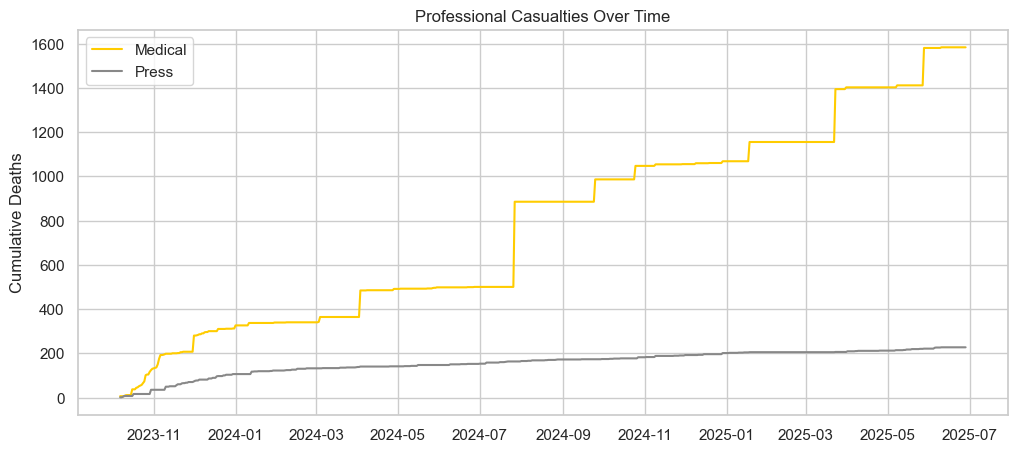

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["med_killed_cum"], label="Medical", color="#FFCC00")
plt.plot(df["date"], df["press_killed_cum"], label="Press", color="#888888")
plt.title("Professional Casualties Over Time")
plt.ylabel("Cumulative Deaths")
plt.legend()
plt.grid(True)
plt.show()

### 5. Data Visualization

1. Daily Deaths Over Time

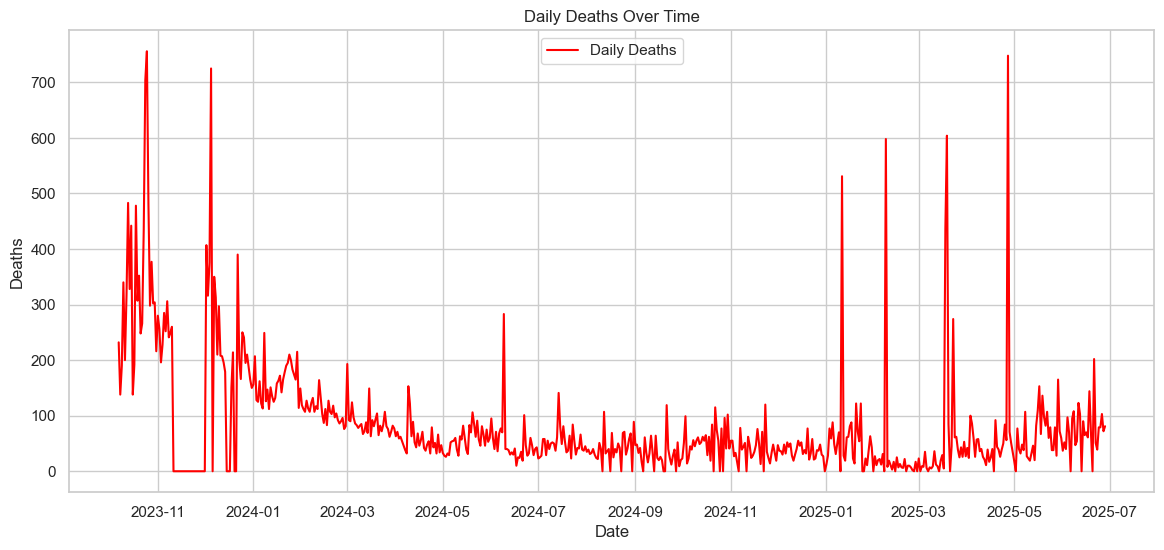

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["killed"], color="red", label="Daily Deaths")
plt.title("Daily Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.grid(True)
plt.legend()
plt.show()

2. Cumulative Deaths vs. Injuries

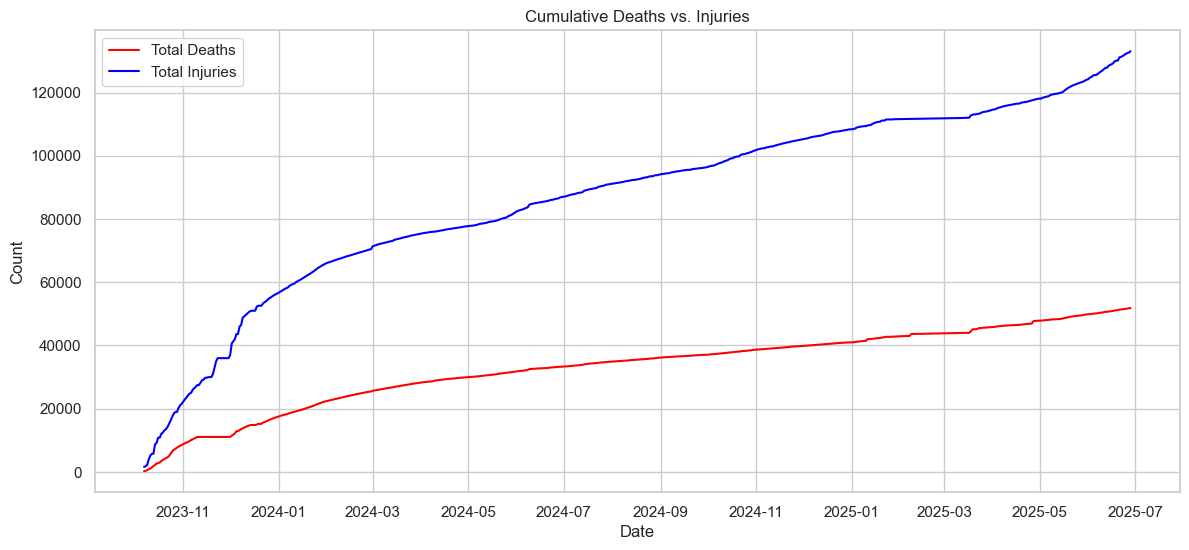

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["killed_cum"], label="Total Deaths", color="red")
plt.plot(df["date"], df["injured_cum"], label="Total Injuries", color="blue")
plt.title("Cumulative Deaths vs. Injuries")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

3. Deaths by Phase (Bar Chart)

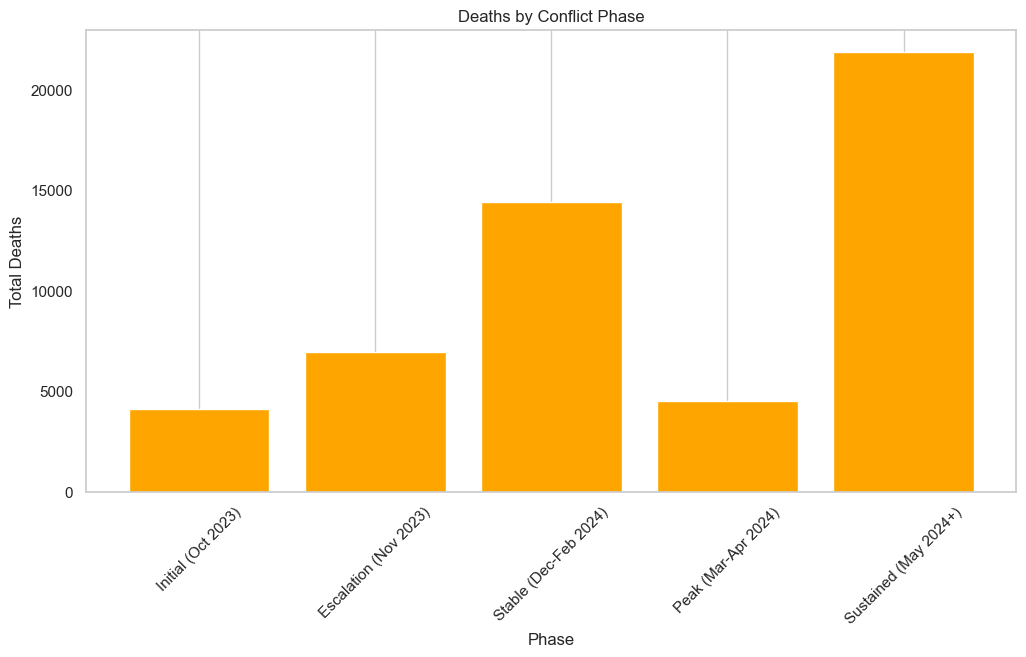

In [14]:
# Define conflict phases
phases = {
    "Initial (Oct 2023)": df[df["date"] <= "2023-10-20"],
    "Escalation (Nov 2023)": df[
        (df["date"] > "2023-10-20") & (df["date"] <= "2023-11-30")
    ],
    "Stable (Dec-Feb 2024)": df[
        (df["date"] > "2023-11-30") & (df["date"] <= "2024-02-29")
    ],
    "Peak (Mar-Apr 2024)": df[
        (df["date"] > "2024-02-29") & (df["date"] <= "2024-04-30")
    ],
    "Sustained (May 2024+)": df[df["date"] > "2024-04-30"],
}

phase_deaths = {phase: phase_df["killed"].sum() for phase, phase_df in phases.items()}

plt.figure(figsize=(12, 6))
plt.bar(phase_deaths.keys(), phase_deaths.values(), color="orange")
plt.title("Deaths by Conflict Phase")
plt.xlabel("Phase")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## Insights Summary

*Key insights*

    1. Demographic Impact: Women represent ~24% of deaths consistently; children ~3%.
    2. Conflict Intensity: Three distinct phases identified - initial outbreak, sustained conflict, and severe escalation.
    3. Medical Impact: 227 medical personnel deaths, mostly early in conflict.
    4. Press Safety: No press deaths recorded after January 2024.
    5. Recent Escalation: March 2024 was the most lethal period with 7,500 deaths.
    6. Data Reliability: Consistent reporting but some days show zero deaths (possible gaps).
    7. Long-term Trauma: Over 130,000 injuries indicate severe public health consequences.